# Écoulement supersonique autour d'un profil isocèle

On vous propose de mettre en place une feuille de calcul de l'écoulement supersonique autour d'un profil ABC isocèle en B. Les calculs doivent être les plus généraux possibles et paramétrés en particulier par le nombre de Mach `Minf` et l'incidence `aoa`.

`Python` sera utilisé ici comme `matlab`. Des fonctionnalités supplémentaires peuvent être ajoutées par l'import de modules, standards à une distribution (comme `math`, `numpy`) ou personnalisés comme ci-dessous. Des fonctionnalités d'édition sont propres à [`Ipython/Notebook`](#ipython).

In [1]:
from IPython.core.display import HTML ; HTML(open("./custom2.css", "r").read()) # notebook style

In [2]:
import math
import matplotlib.pyplot as plt
import aerokit.aero.degree     as deg # import trigo functions with degree unit support
import aerokit.aero.Isentropic as Is  # import Isentropic functions
import aerokit.aero.ShockWave  as sw  # import Shock Wave functions
import aerokit.aero.Supersonic as sup # import supersonic related functions
%matplotlib inline
import aerokit, sys ; print(sys.version) ; print(aerokit.__version__)

3.9.7 (default, Sep  3 2021, 12:37:55) 
[Clang 12.0.5 (clang-1205.0.22.9)]
1.1.3


Les paramètres suivants sont définis comme des variables globales, que l'on peut utiliser directement dans les fonctions (comme $\gamma$ par exemple). Le profil isocèle a un angle BAC de 10° au bord d'attaque. Il est défini est tracé plus bas. La base (ou corde) du profil est normalisée à AC=1. On commence par définir les fonctions permettant de calculer rapidement les quantités totales $P_t/P$ et $T_t/T$.

## Étude aérodynamique de la configuration

On développe des fonctions qui doivent calculer la pression statique et le nombre de Mach sur chacune des parois, en fonction des paramètres globaux de la configuration : nombre de Mach de vol et angle d'incidence.

Il faut développer les calculs dans le cas général, en particulier en testant les sens de déviation (en fonction de l'incidence) si nécessaire, comme proposé pour la zone 1. Ces fonctions permettront les calculs automatiques en fin de séance.

angle of attack  (deg): 6.0
angle of profile (deg): 10.0


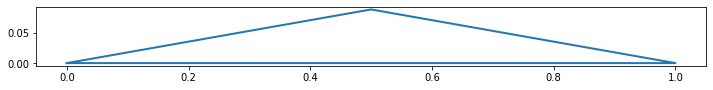

In [3]:
# definition of problem parameters : far upstream quantities and geometry
Minf = 2.4 ; Tinf=216. ; pinf = 5500. ; gam = 1.4
aoa  = 6. ;      print("angle of attack  (deg): {}".format(aoa))
prof_ang = 10. ; print("angle of profile (deg): {}".format(prof_ang))
AC = 1.
AB = BC = AC/2./deg.cos(prof_ang)
#
fig, ax = plt.subplots(figsize=(12,2)) ; ax.set_aspect("equal")
ax.plot([0, .5, 1., 0.], [0., .5*deg.tan(prof_ang), 0., 0.], linewidth=2)

### déviation générique (paroi basse)

On définit une fonction générique de calcul d'un état aval par déviation abrupte : soit un choc si la déviation est positive, une détente sinon.

In [4]:
def pM_fromdev(p0, M0, dev):
    pt0 = p0*Is.PtPs_Mach(M0)
    if (dev > 0.):
        # calcul choc
        sig = sw.sigma_Mach_deflection(M0, dev)
        Mn0 = M0*deg.sin(sig) 
        Mn1 = sw.downstream_Mn(Mn0)
        p1  = p0 *sw.Ps_ratio(Mn0) 
        pt1 = pt0*sw.Pt_ratio(Mn0) 
        M1  = Mn1/deg.sin(sig-dev) 
    else:
        # calcul détente
        omg0 = sup.PrandtlMeyer_Mach(M0)
        omg1 = omg0 - dev
        M1   = sup.Mach_PrandtlMeyer(omg1)
        pt1  = pt0
        p1   = pt1/Is.PtPs_Mach(M1)
    return p1, M1

### zone 1 (extrados avant)

In [5]:
def compute_zone1(p0, M0, aoa, verbose=False):
    #
    dev = prof_ang-aoa    ## STUDENT: dev = ... # define flow deviation using wall angle and angle of attack
    p1, M1 = pM_fromdev(p0, M0, dev)
    if verbose:
        print("state 1:\n  Mach = {:.3f}\n  P1   = {:5.0f}\n  Pt1  = {:5.0f}".format(M1, p1, p1*Is.PiPs_Mach(M1) ))
    return p1, M1
#
# function is used with above Minf and oao
print("state 0:\n  Mach = {:.3f}\n  P0   = {:5.0f}\n  Pt0  = {:5.0f}".format(Minf, pinf, pinf*Is.PiPs_Mach(Minf)))
p1, M1 = compute_zone1(pinf, Minf, aoa=aoa, verbose=True)

state 0:
  Mach = 2.400
  P0   =  5500
  Pt0  = 80410
state 1:
  Mach = 2.238
  P1   =  7071
  Pt1  = 80280


### zone 2 (extrados arrière)

On montrera que pour cette zone, la déviation ne dépend pas de l'angle d'incidence (donc pas de test). Les données d'entrée (amont) pour le calcul de la zone 2 sont celles de la zone 1.

In [6]:
def compute_zone2(p1, M1, aoa, verbose=False):
    # on utilise néanmoins la fonction déjà implémentée (qui ne passera jamais le test dev <0)
    dev = -2*prof_ang   # deviation is independent of angle of attack
    p2, M2 = pM_fromdev(p1, M1, dev)
    if verbose:
        print("state 2:\n  Mach = {:.3f}\n  P2   = {:5.0f}\n  Pt2  = {:5.0f}".format(M2, p2, p2*Is.PiPs_Mach(M2)))
    return p2, M2
#
p2, M2 = compute_zone2(p1, M1, aoa=aoa, verbose=True)

state 2:
  Mach = 3.158
  P2   =  1727
  Pt2  = 80280


### zone 3 (intrados)

Attention, pour un choc, de déviation (négative) vers le bas, il est fortement conseillé d'utiliser par symétrie une déviation positive dans la polaire.

In [7]:
def compute_zone3(p0, M0, aoa, verbose=False):
    # la déviation réelle est (-aoa) mais on renverse le problème
    dev = -(-aoa)
    p3, M3 = pM_fromdev(p0, M0, dev)
    if verbose:
        print("state 3:\n  Mach = {:.3f}\n  P3   = {:5.0f}\n  Pt3  = {:5.0f}".format(M3, p3, p3*Is.PiPs_Mach(M3)))
    return p3, M3
#
p3, M3 = compute_zone3(pinf, Minf, aoa=aoa, verbose=True)

state 3:
  Mach = 2.159
  P3   =  7978
  Pt3  = 79991


### sillage (facultatif)

Le calcul de l'écoulement (zones 5 et 6) dans le sillage est ici facultatif. Quelques questions sont néanmoins posées :
1. quelle est l'orientation attendue du sillage ?
2. quels sont les phénomènes attendus ?
3. quelle contrainte doit être satisfaite ?
4. quel est l'impact sur les efforts (traînée, portance)
  - dans un cas fluide parfait ?
  - en tenant compte des effets visqueux ?

<div class="isae-answer">
    1. le sillage reprend l'orientation de l'écoulement amont ; c'est ce qui est attendu en champ lointain, c'est aussi le résultat champ proche (au bord de fuite) de la théorie petite perturbations.<br>
    2. selon l'incidence, on peut en déduire les déviations et définir les phénomènes comme des chocs ou des détentes.<br>
    3. les écoulements extrados 2 et intrados 3 se rejoignent ; après compression et/ou détente, en 4 et 5, séparés par une ligne de glissement, ils ont la même direction mais aussi la même pression. Si on fait un calcul en imposant arbitrairement la direction, le résultat ne sera pas équilibré en pression (c'est la condition à utiliser pour obtenir la bonne direction).<br>
    4. en fluide parfait, les écoulements 4 et 5 n'exerce aucune influence sur le profil ; en fluide visqueux, l'interaction des éventuels choc avec la couche limite peut remonter et impacter portance et traînée.
</div>

### Équilibre de la ligne de glissement

Une bonne estimation de l'angle du sillage est celle donnée par la théorie linéarisée, identique à ce que donnerait un calcul par caractéristiques en supposant toutes les transformations isentropiques : le sillage retrouve immédiatement l'angle de l'écoulement amont.

In [8]:
def compute_zone4(p2, M2, th2, thwake, verbose=False):
    dev = thwake - th2
    p4, M4 = pM_fromdev(p2, M2, dev)
    if verbose:
        print("state 4:\n  Mach = {:.3f}\n  P4   = {:5.0f}\n  Pt4  = {:5.0f}".format(M4, p4, p4*Is.PiPs_Mach(M4)))
    return p4, M4
#
def compute_zone5(p3, M3, th3, thwake, verbose=False):
    dev = -(thwake - th3)
    p5, M5 = pM_fromdev(p3, M3, dev)
    if verbose:
        print("state 5:\n  Mach = {:.3f}\n  P5   = {:5.0f}\n  Pt5  = {:5.0f}".format(M5, p5, p5*Is.PiPs_Mach(M5)))
    return p5, M5

p4, M4 = compute_zone4(p2, M2, -prof_ang, aoa, verbose=True)
p5, M5 = compute_zone5(p3, M3, 0.,        aoa, verbose=True)
print("le sillage a été calculé arbitrairement à {:.2f}° avec un écart relatif de pression de {:.2f}%".format(aoa, abs(p5-p4)/(p4+p5)*2*100))


state 4:
  Mach = 2.315
  P4   =  5413
  Pt4  = 69285
state 5:
  Mach = 2.396
  P5   =  5502
  Pt5  = 79991
le sillage a été calculé arbitrairement à 6.00° avec un écart relatif de pression de 1.63%


In [9]:
from scipy.optimize import newton

def deltaP(thwake):
    p4, M4 = compute_zone4(p2, M2, -prof_ang, thwake)
    p5, M5 = compute_zone5(p3, M3, 0.,        thwake)
    return p4-p5

thwake = newton(deltaP, aoa) # itérations avec initialisation à aoa
print(f"le sillage est équilibré pour theta = {thwake:.2f}° à une incidence de {aoa:.2f}°")
p4, M4 = compute_zone4(p2, M2, -prof_ang, thwake, verbose=True)
p5, M5 = compute_zone5(p3, M3, 0.,        thwake, verbose=True)

le sillage est équilibré pour theta = 6.13° à une incidence de 6.00°
state 4:
  Mach = 2.308
  P4   =  5456
  Pt4  = 69075
state 5:
  Mach = 2.402
  P5   =  5456
  Pt5  = 79991


## Étude des efforts

Le calcul des efforts est défini par
$$ \vec{F} =\int_{ABC} \!\!-p \vec{n}\,d\!S $$
Montrer que la normalisation de F par $1/2\,S\rho_0\,V_0^2$ en Cx, Cz revient à diviser par $AC\,\frac\gamma2 p_0 M_0^2$.

### calcul de portance et traînée

On propose de tout d'abord calculer les efforts normaux Cn et tangentiels Ct au profil puis de les projeter dans le repère aérodynamique.

In [10]:
def compute_aerocoeff(M0, aoa):
    # one can use Pinf or normalize value
    p0 = 1.
    Fref = .5*AC*p0*gam*M0**2
    p1, M1 = compute_zone1(p0, M0, aoa)
    p2, M2 = compute_zone2(p1, M1, aoa)
    p3, M3 = compute_zone3(p0, M0, aoa)
    #
    # p1 = p2 = p3 = p0 # check integration on closed path
    ct = AB*deg.sin(prof_ang)*(p1-p2) / Fref    ## STUDENT: ct = ... # expression with p1, p2, p3, AB ...
    cn = AC*(p3 - .5*(p1+p2)) / Fref            ## STUDENT: cn = ...
    #
    cx =  ct * deg.cos(aoa) + cn * deg.sin(aoa)
    cz = -ct * deg.sin(aoa) + cn * deg.cos(aoa)
    return cx, cz


### tracé de la polaire

On vous propose ici de comparer aux résultats de la théorie linéarisée (petites perturbations). Des discontinuités ou cassures dans vos résultats sont certainement dû à des erreurs dans le traitement de vos tests (zone 1 et 3).

1. s'attend-on à trouver une traînée non nulle ?
2. quelle est l'incidence de portance nulle ?
3. quelle est l'incidence de traînée minimale ?
4. superposer différentes courbes pour voir l'effet de compressibilité <br>
   (la dernière ligne commentée permet de tracer les résultats mémorisés à l'exécution précédente de la cellule).

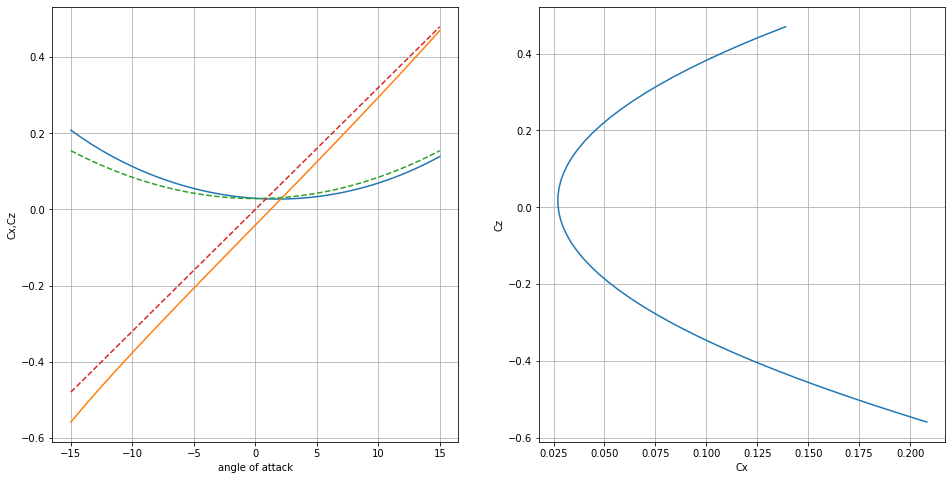

In [11]:
import numpy as np
#
n = 50
Minf = 2.4
aoa_range = np.linspace(-15., 15., n)
cx = np.zeros(n)
cz = np.zeros(n)
cxlin = np.zeros(n)
czlin = np.zeros(n)
for i in range(n):
    cx[i], cz[i] = compute_aerocoeff(Minf, aoa_range[i])
cxlin = (2*deg.tan(prof_ang)**2 + 4*np.radians(aoa_range)**2)/math.sqrt(Minf**2-1.)
czlin = 4*np.radians(aoa_range)/math.sqrt(Minf**2-1.)
#
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))

ax1.set_xlabel("angle of attack") ; ax1.set_ylabel("Cx,Cz") ; ax1.grid()
ax1.plot(aoa_range,cx)  
ax1.plot(aoa_range,cz) 
ax1.plot(aoa_range,cxlin, '--')  
ax1.plot(aoa_range,czlin, '--') 
ax2.set_xlabel("Cx") ; ax2.set_ylabel("Cz")  ; ax2.grid()
ax2.plot(cx,cz) 
#ax2.plot(cx,cz,cxprev,czprev) ; cxprev=cx ; czprev=cz

---

<a id="ipython"></a>
## Ipython et notebook : usage

* le notebook utilise la langage de base python en version améliorée, Ipython, qui permet la complétion des noms (variables, fonctions, modules) avec la touche tabulation
* toutes les cellules peuvent être modifiées par un double-clic et sont réinterprêtées avec `shift-entrée`
* l'ensemble de la feuille peut être exécutée avec le menu `Cell/run all cells`
* **n'oubliez pas de sauvegarder régulièrement votre feuille** (bouton _enregistrer_)
